In [ ]:
!pip install opendatasets
!pip install pandas

In [ ]:
import opendatasets as od

In [ ]:
od.download(
    "https://www.kaggle.com/datasets/ipythonx/mvtec-ad?select=bottle")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kathy07
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/ipythonx/mvtec-ad


100%|██████████| 4.91G/4.91G [00:37<00:00, 141MB/s]


In [ ]:
!pip install torchvision

In [ ]:
file =('/content/mvtec-ad/bottle/train')

In [ ]:
import torch

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt

import torch
from torchvision import datasets, transforms


In [ ]:
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    '/content/mvtec-ad/bottle/train',
    transform=train_transform
)

In [ ]:
#here dataloader is a generator. To get data from it we have to iterate with a for loop or call Next ()

In [ ]:
dataloader = torch.utils.data.DataLoader(train_dataset, batch_size = 32, shuffle = True)

In [ ]:
images, labels = next(iter(dataloader))


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

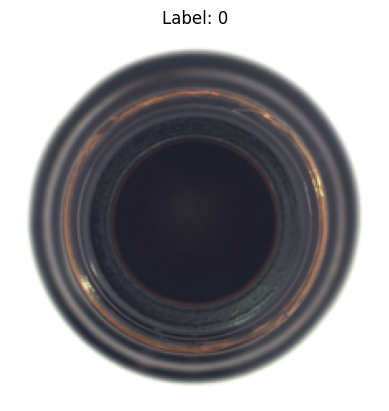

In [ ]:
img = images[0]              # [C, H, W]
img = img.permute(1, 2, 0)   # → [H, W, C]

plt.imshow(img)
plt.title(f"Label: {labels[0].item()}")
plt.axis('off')

since the train contains only good images, and its a binary classification task to show FastViT industrial defect detection. I am going to bring in "damages" data from test folder and create new folders for traim, test and validation.

In [ ]:
#data reconstructing
#now i want to do is bring in data from test and train make it into three main directories. Test, Train and validation dataset
#source mapping?
import os
import shutil

path = '/content/mvtec-ad/bottle/train'
os.listdir(path)
path2 = '/content/mvtec-ad/bottle/test'
os.listdir(path2)

['broken_large', 'contamination', 'good', 'broken_small']

In [ ]:
import os
import shutil
import random

# 1. Define where the new data will live
base_dir = '/content/industrial_data'
splits = ['train', 'val', 'test']
classes = ['good', 'damaged']

# Create the folders: industrial_data/train/good, etc.
for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

print("Empty folder structure created at:", base_dir)

Empty folder structure created at: /content/industrial_data


Gather , Shuffle , Split

In [ ]:
def get_split_files(file_list, train_perc=0.7, val_perc=0.15):
  random.seed(42) # Keeps the split identical every time you run it
  random.shuffle(file_list)
  n = len(file_list)
  train_idx = int(n * train_perc)
  val_idx = int(n * (train_perc + val_perc))
  return file_list[:train_idx], file_list[train_idx:val_idx], file_list[val_idx:]

# --- GATHER GOOD IMAGES ---
# From your screenshot: 'train/good' AND 'test/good'
good_src1 = '/content/mvtec-ad/bottle/train/good'
good_src2 = '/content/mvtec-ad/bottle/test/good'

all_good = [os.path.join(good_src1, f) for f in os.listdir(good_src1) if f.endswith('.png')]
all_good += [os.path.join(good_src2, f) for f in os.listdir(good_src2) if f.endswith('.png')]

# --- GATHER DAMAGED IMAGES ---
# From your screenshot: all test folders EXCEPT 'good'
damaged_root = '/content/mvtec-ad/bottle/test'
all_damaged = []
for folder in os.listdir(damaged_root):
    if folder != 'good':
        folder_path = os.path.join(damaged_root, folder)
        if os.path.isdir(folder_path):
            all_damaged += [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.png')]

# Apply the 70/15/15 split
good_train, good_val, good_test = get_split_files(all_good)
damaged_train, damaged_val, damaged_test = get_split_files(all_damaged)

print(f"Total processed: {len(all_good)} Good, {len(all_damaged)} Damaged")

Total processed: 229 Good, 63 Damaged


In [ ]:
print(f"Total processed: {len(good_test)} Good, {len(damaged_test)} Damaged")

Total processed: 35 Good, 10 Damaged


In [ ]:
def copy_to_dest(files, destination):
    for f in files:
        shutil.copy(f, destination)

# Copy Good images
copy_to_dest(good_train, os.path.join(base_dir, 'train/good'))
copy_to_dest(good_val, os.path.join(base_dir, 'val/good'))
copy_to_dest(good_test, os.path.join(base_dir, 'test/good'))

# Copy Damaged images
copy_to_dest(damaged_train, os.path.join(base_dir, 'train/damaged'))
copy_to_dest(damaged_val, os.path.join(base_dir, 'val/damaged'))
copy_to_dest(damaged_test, os.path.join(base_dir, 'test/damaged'))

print("Success! Data is now organized for FastViT.")

Success! Data is now organized for FastViT.


In [ ]:
# You might need to install 'timm' (PyTorch Image Models) to get FastViT easily
!pip install timm

import timm
import torch.nn as nn

# Load a small, fast version of FastViT (pre-trained on ImageNet)
model = timm.create_model('fastvit_t8', pretrained=True)

# We need to change the final layer (the "head") to output 2 classes instead of 1000
num_features = model.head.fc.in_features
model.head.fc = nn.Linear(num_features, 2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"FastViT is ready on: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

FastViT is ready on: cuda


*Class Imbalancee - to tackle this problem: using Loss Function*

In [ ]:
# Calculate weights: Total Samples / (Number of Classes * Samples in Class)
# A simpler way: give 'Damaged' roughly 3.6x the weight of 'Good'
weights = torch.tensor([1.0, 3.6]).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

**Training**

In [ ]:
from torchvision import datasets, transforms

# 1. Define the transform (Standard for FastViT)
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# 2. POINT TO THE NEW DATA (The stuff we engineered)
train_dataset = datasets.ImageFolder('/content/industrial_data/train', transform=data_transform)
val_dataset = datasets.ImageFolder('/content/industrial_data/val', transform=data_transform)
test_dataset = datasets.ImageFolder('/content/industrial_data/test', transform=data_transform)

# 3. RE-CREATE THE LOADERS
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Sync Complete!")
print(f"Training on: {len(train_dataset)} images ({train_dataset.classes})")
print(f"Validating on: {len(val_dataset)} images")

Sync Complete!
Training on: 170 images (['damaged', 'good'])
Validating on: 41 images


In [ ]:
# --- 4. THE COMPLETE TRAINING & VALIDATION LOOP ---
from tqdm.auto import tqdm
epochs = 10

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # --- VALIDATION PHASE ---
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()


    avg_train_loss = train_loss / len(train_loader)
    val_acc = 100 * val_correct / val_total
    print(f"Summary -> Train Loss: {avg_train_loss:.4f} | Val Accuracy: {val_acc:.2f}%")
    print("-" * 30)

print("Training Complete! Your FastViT model is now an Inspector.")

Epoch 1 Training:   0%|          | 0/6 [00:00<?, ?it/s]

Summary -> Train Loss: 0.4219 | Val Accuracy: 80.49%
------------------------------


Epoch 2 Training:   0%|          | 0/6 [00:00<?, ?it/s]

Summary -> Train Loss: 0.2062 | Val Accuracy: 80.49%
------------------------------


Epoch 3 Training:   0%|          | 0/6 [00:00<?, ?it/s]

...

Summary -> Train Loss: 0.0233 | Val Accuracy: 87.80%
------------------------------


Epoch 9 Training:   0%|          | 0/6 [00:00<?, ?it/s]

Summary -> Train Loss: 0.0171 | Val Accuracy: 87.80%
------------------------------


Epoch 10 Training:   0%|          | 0/6 [00:00<?, ?it/s]

Summary -> Train Loss: 0.0259 | Val Accuracy: 92.68%
------------------------------
Training Complete! Your FastViT model is now an Inspector.


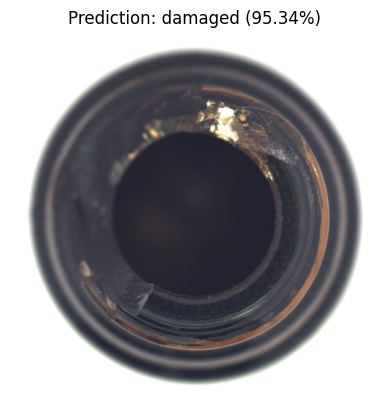

In [ ]:
import PIL.Image as Image

# 1. Pick a random test image (Update this path to an actual file in your test/damaged folder)
test_image_path = '/content/industrial_data/test/damaged/' + os.listdir('/content/industrial_data/test/damaged')[0]

# 2. Preprocess
img = Image.open(test_image_path).convert('RGB')
img_tensor = data_transform(img).unsqueeze(0).to(device)

# 3. Predict
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    probabilities = torch.nn.functional.softmax(output, dim=1)
    confidence, predicted = torch.max(probabilities, 1)

# 4. Map index to class name
class_names = train_dataset.classes # ['damaged', 'good']
result = class_names[predicted.item()]

# 5. Show Result
plt.imshow(img)
plt.title(f"Prediction: {result} ({confidence.item()*100:.2f}%)")
plt.axis('off')
plt.show()

In [ ]:
# Save the model weights
torch.save(model.state_dict(), 'fastvit_bottle_inspector.pth')
print("Model saved as fastvit_bottle_inspector.pth")

Model saved as fastvit_bottle_inspector.pth


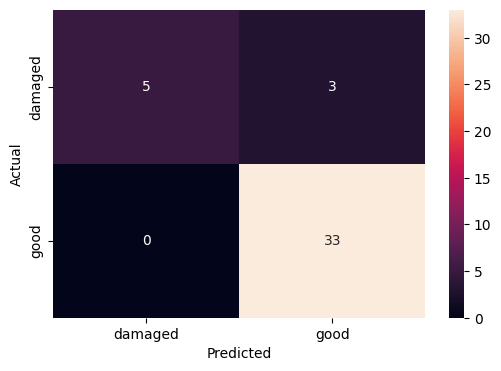

              precision    recall  f1-score   support

     damaged       1.00      0.62      0.77         8
        good       0.92      1.00      0.96        33

    accuracy                           0.93        41
   macro avg       0.96      0.81      0.86        41
weighted avg       0.93      0.93      0.92        41



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Plotting the matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

**LOADING WEIGHTS**

In [ ]:
# 1. Create a fresh, empty FastViT model
#model = timm.create_model('fastvit_t8', pretrained=False, num_classes=2)

# 2. Inject the "Saved Brain" into the empty model
#model.load_state_dict(torch.load('fastvit_bottle_inspector.pth'))

# 3. Ready to go!
#model.eval()
#print("Model memory restored successfully!")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Create a specific folder in your Drive so it's organized
import os
drive_folder = '/content/drive/MyDrive/Bottle_Project_2026'
os.makedirs(drive_folder, exist_ok=True)

# Save the model weights there
save_path = os.path.join(drive_folder, 'fastvit_bottle_inspector.pth')
torch.save(model.state_dict(), save_path)

print(f"✅ Success! Your model is now permanently saved at: {save_path}")

✅ Success! Your model is now permanently saved at: /content/drive/MyDrive/Bottle_Project_2026/fastvit_bottle_inspector.pth
